<a href="https://colab.research.google.com/github/3dgarxx3/Mineria_Datos/blob/main/IA_1_Verano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2614/1106386471.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_binary500.fillna(method = 'ffill', inplace=True)


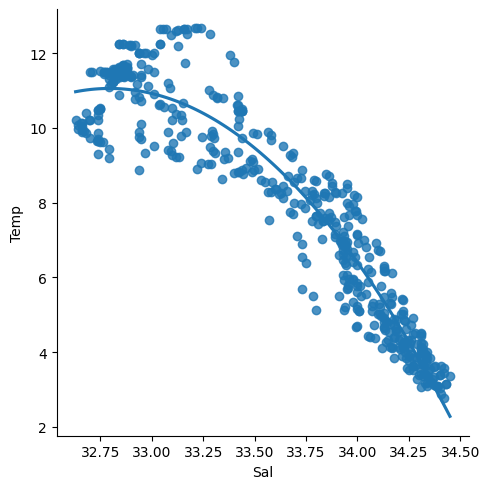

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/bottle1.csv')
df_binary = df[['Salnty','T_degC']]

df_binary.columns = ['Sal','Temp']
df_binary500 = df_binary[:][:500]

df_binary500.fillna(method = 'ffill', inplace=True)
df_binary500.dropna(inplace=True)
sns.lmplot(x='Sal',y='Temp',data=df_binary500,order=2,ci = None)
plt.show()

In [ ]:
X = np.array(df_binary500['Sal']).reshape(-1,1)
y = np.array(df_binary500['Temp']).reshape(-1,1)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25)
regr = LinearRegression()
regr.fit(X_train,y_train)
print(regr.score(X_test,y_test))

0.8413740829869618


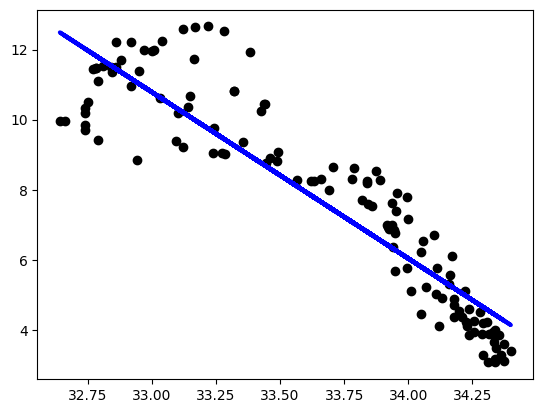

In [ ]:
y_pred = regr.predict(X_test)
plt.scatter(X_test,y_test,color='black')
plt.plot(X_test,y_pred,color='blue',linewidth=3)
plt.show()

In [ ]:
X_New = np.array([[5],[6]])
prediccion = regr.predict(X_New)
print(prediccion)

[[143.71443211]
 [138.96698116]]


<Axes: xlabel='longitude', ylabel='latitude'>

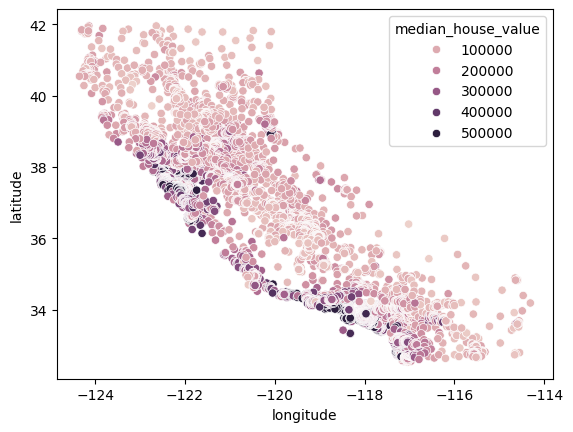

In [ ]:
import pandas as pd
datos = pd.read_csv('/content/housing.csv',usecols = ['longitude','latitude','median_house_value'])
datos.head()
import seaborn as sns
sns.scatterplot(data = datos,x='longitude',y='latitude',hue='median_house_value')

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(datos[['latitude','longitude']],
                                                 datos[['median_house_value']],test_size=0.33,random_state=0)

<Axes: xlabel='longitude', ylabel='latitude'>

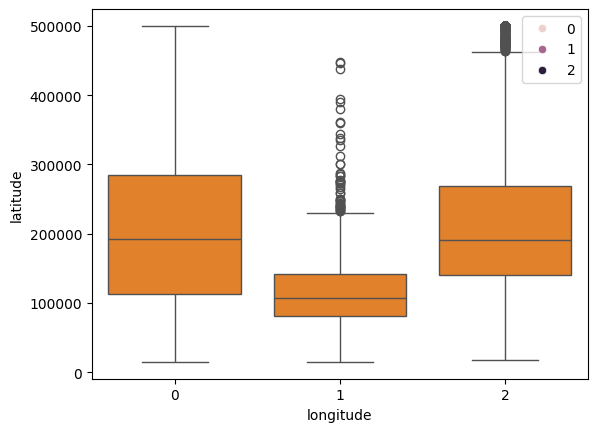

In [ ]:
from sklearn import preprocessing
X_train_norm = preprocessing.normalize(x_train)
X_test_norm = preprocessing.normalize(x_test)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=0,n_init='auto')
kmeans.fit(X_train_norm)

sns.scatterplot(data = x_train, x ='longitude', y='latitude', hue=kmeans.labels_)

sns.boxplot(x = kmeans.labels_, y = y_train['median_house_value'])